# 삼각방정식과 삼각부등식

단위원·주기성을 이용해 **일반해**를 구하고, 구간에서 부등식을 푼다.


## 1. 기본 삼각방정식과 일반해


$n \in \mathbb{Z}$ 에 대해:

| 방정식 | 일반해 |
|--------|--------|
| $\sin x = 0$ | $x = n\pi$ |
| $\sin x = 1$ | $x = \tfrac{\pi}{2} + 2n\pi$ |
| $\sin x = \sin\alpha$ | $x = n\pi + (-1)^n \alpha$ |
| $\cos x = \cos\alpha$ | $x = 2n\pi \pm \alpha$ |
| $\tan x = \tan\alpha$ | $x = n\pi + \alpha$ |


In [1]:
import sympy as sp
from sympy import sin, cos, tan, pi, Eq, solveset, S, Interval
sp.init_printing()

x = sp.symbols('x', real=True)

eqs = [
    Eq(sin(x), sp.Rational(1, 2)),
    Eq(cos(x), sp.sqrt(2)/2),
    Eq(tan(x), 1),
]

for eq in eqs:
    # 실수 전체 일반해 (ImageSet / Union)
    sol = solveset(eq, x, domain=S.Reals)
    print("=" * 40)
    display(eq)
    display(sol)


**solveset(eq, x, domain=S.Reals)**: <br>
=> 주기적 일반해를 `ImageSet` 등으로 표현

**sp.solve**: <br>
=> 주된(principal) 해만 줄 수 있음 — 일반해는 `solveset` 선호


## 2. 구간 $[0, 2\pi)$ 에서의 해


In [2]:
interval = Interval(0, 2*pi, right_open=True)

for eq in [
    Eq(sin(x), sp.Rational(1, 2)),
    Eq(cos(x), -sp.Rational(1, 2)),
    Eq(tan(x), -1),
]:
    sol = solveset(eq, x, domain=interval)
    print("=" * 40)
    display(eq)
    display(sol)


## 3. 간단한 삼각부등식


In [3]:
from sympy import solve_univariate_inequality

# sin x > 1/2  on [0, 2π]
ineq = sin(x) > sp.Rational(1, 2)
# solve_univariate_inequality는 한 주기 표현이 제한적일 수 있어
# 구간을 좁혀 수치·기호 병행
sol_ineq = solveset(ineq, x, domain=Interval(0, 2*pi))
print("sin x > 1/2  on [0, 2π]")
display(sol_ineq)

# cos x ≤ 0 on [0, 2π]
sol_cos = solveset(cos(x) <= 0, x, domain=Interval(0, 2*pi))
print("cos x ≤ 0  on [0, 2π]")
display(sol_cos)


sin x > 1/2  on [0, 2π]


cos x ≤ 0  on [0, 2π]


## 4. 시각화: $\sin x > 1/2$


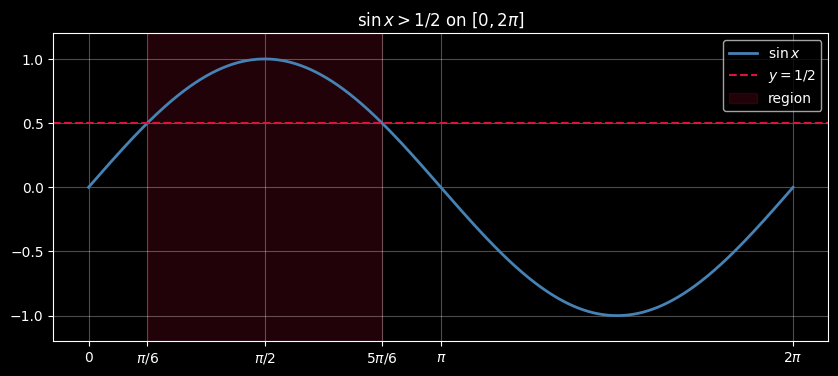

In [5]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 2*np.pi, 1000)
ys = np.sin(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, color='steelblue', lw=2, label=r'$\sin x$')
plt.axhline(0.5, color='crimson', ls='--', label=r'$y=1/2$')

# 해 구간 강조: (π/6, 5π/6)
mask = ys > 0.5
plt.fill_between(xs, -1.2, 1.2, where=mask, color='crimson', alpha=0.15, label='region')

plt.xticks([0, np.pi/6, np.pi/2, 5*np.pi/6, np.pi, 2*np.pi],
           ['0', r'$\pi/6$', r'$\pi/2$', r'$5\pi/6$', r'$\pi$', r'$2\pi$'])
plt.ylim(-1.2, 1.2)
plt.title(r'$\sin x > 1/2$ on $[0, 2\pi]$')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()


$[0, 2\pi]$에서 $\sin x > 1/2$ 의 해: $\dfrac{\pi}{6} < x < \dfrac{5\pi}{6}$.  
일반해로 확장하려면 주기 $2\pi$를 더한다.
